# 01 - Data Audit and EDA
Audits the untouched Craigslist file and creates evidence of missingness, outliers, distributions, and categorical frequencies.

In [1]:
from pathlib import Path
import sys,warnings
warnings.filterwarnings("ignore")
ROOT=Path.cwd(); ROOT=ROOT.parent if ROOT.name=="notebooks" else ROOT
sys.path.insert(0,str(ROOT)) if str(ROOT) not in sys.path else None
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.utils import *
ensure_dirs(); pd.set_option("display.max_columns",100)
print("Project root:",ROOT)

Project root: /Users/sangeetasarker/Downloads/cse437-used-car-price-prediction-GROUP_NUMBER


In [2]:
raw=read_raw(); print("Raw shape:",raw.shape); display(raw.head())

Raw shape: (426880, 26)


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [3]:
audit={"rows":int(raw.shape[0]),"columns":int(raw.shape[1]),"duplicates":int(raw.duplicated().sum()),"columns_list":raw.columns.tolist()}
missing=raw.isna().sum().sort_values(ascending=False); miss=pd.DataFrame({"missing_n":missing,"missing_pct":100*missing/len(raw)})
display(miss.head(15)); save_json(audit,RESULTS_DIR/"audit.json"); miss.to_csv(RESULTS_DIR/"missingness_raw.csv")

,missing_n,missing_pct
county,426880,100.000000
size,306361,71.767476
cylinders,177678,41.622470
condition,174104,40.785232
VIN,161042,37.725356
drive,130567,30.586347
paint_color,130203,30.501078
type,92858,21.752717
manufacturer,17646,4.133714
title_status,8242,1.930753


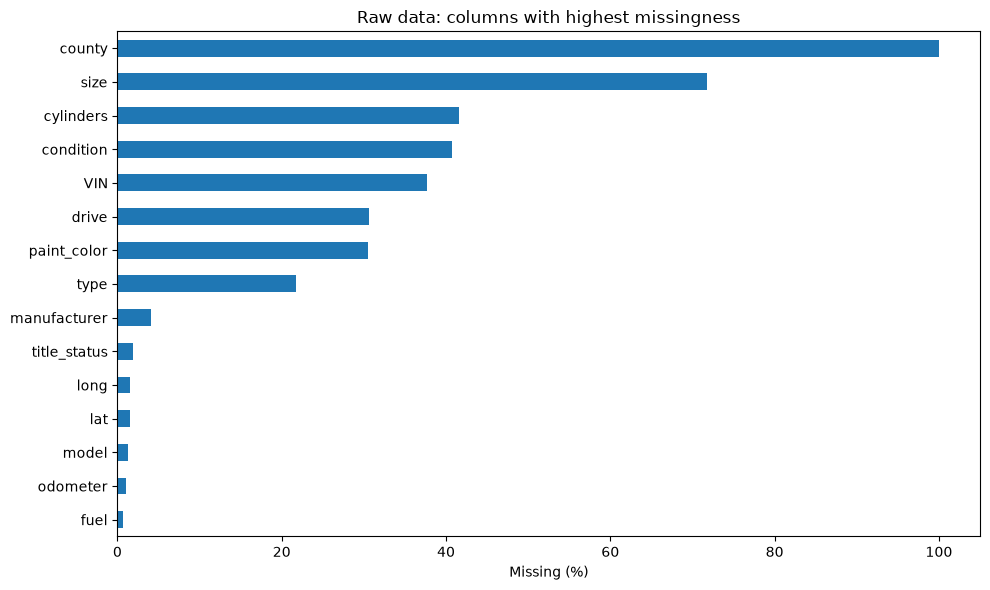

In [4]:
fig,ax=plt.subplots(figsize=(10,6)); miss.head(15).sort_values("missing_pct")["missing_pct"].plot.barh(ax=ax); ax.set(xlabel="Missing (%)",title="Raw data: columns with highest missingness"); fig.tight_layout(); fig.savefig(FIGURES_DIR/"01_raw_missingness.png",dpi=160); plt.show()

In [5]:
num=[c for c in ["price","year","odometer","lat","long"] if c in raw]; summary=raw[num].describe(percentiles=[.01,.25,.5,.75,.99]).T; display(summary); summary.to_csv(RESULTS_DIR/"raw_numeric_summary.csv")

,count,mean,std,min,1%,25%,50%,75%,99%,max
price,426880.0,75199.033187,1.218228e+07,0.000000,0.000000,5900.000000,13950.0000,26485.750000,66995.000000,3.736929e+09
year,425675.0,2011.235191,9.452120e+00,1900.000000,1967.000000,2008.000000,2013.0000,2017.000000,2020.000000,2.022000e+03
odometer,422480.0,98043.331443,2.138815e+05,0.000000,2.000000,37704.000000,85548.0000,133542.500000,280000.000000,1.000000e+07
lat,420331.0,38.493940,5.841533e+00,-84.122245,25.844662,34.601900,39.1501,42.398900,48.754959,8.239082e+01
long,420331.0,-94.748599,1.836546e+01,-159.827728,-149.869094,-111.939847,-88.4326,-80.832039,-71.081834,1.738855e+02


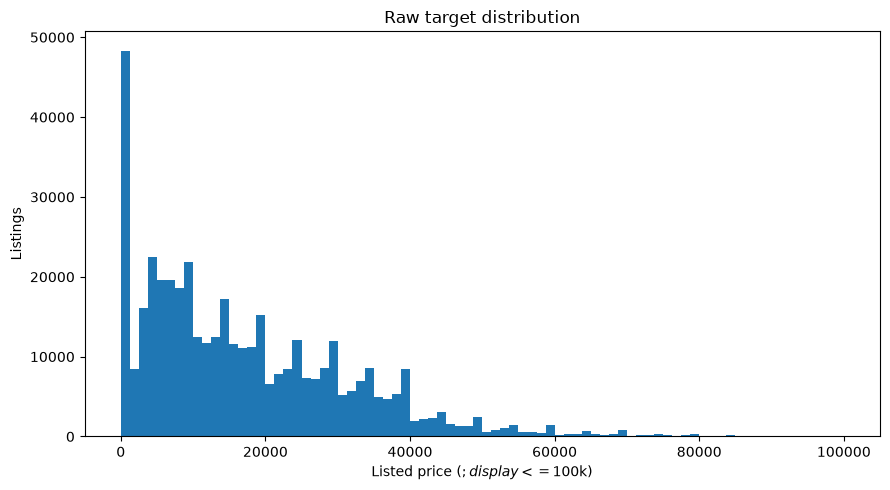

In [6]:
p=pd.to_numeric(raw.price,errors="coerce"); p=p[(p>=0)&(p<=100000)]; fig,ax=plt.subplots(figsize=(9,5)); ax.hist(p,bins=80); ax.set(xlabel="Listed price ($; display <= $100k)",ylabel="Listings",title="Raw target distribution"); fig.tight_layout(); fig.savefig(FIGURES_DIR/"02_raw_price_distribution.png",dpi=160); plt.show()

In [7]:
for c in ["manufacturer","state","condition","fuel","transmission","type","region"]:
    if c in raw:
        print("\n",c,"unique=",raw[c].nunique(dropna=True)); display(raw[c].value_counts(dropna=False).head(10).to_frame("count"))


 manufacturer unique= 42


,count
manufacturer,
ford,70985
chevrolet,55064
toyota,34202
honda,21269
nissan,19067
jeep,19014
ram,18342
NaN,17646
gmc,16785



 state unique= 51


,count
state,
ca,50614
fl,28511
tx,22945
ny,19386
oh,17696
or,17104
mi,16900
nc,15277
wa,13861



 condition unique= 6


...

,count
transmission,
automatic,336524
other,62682
manual,25118
NaN,2556



 type unique= 13


,count
type,
NaN,92858
sedan,87056
SUV,77284
pickup,43510
truck,35279
other,22110
coupe,19204
hatchback,16598
wagon,10751



 region unique= 404


,count
region,
columbus,3608
jacksonville,3562
spokane / coeur d'alene,2988
eugene,2985
fresno / madera,2983
orlando,2983
bend,2982
omaha / council bluffs,2982
new hampshire,2981
